Saved augmentation plot to augmentation_plot.png
Saved dropout loss curves to dropout_loss_curves.png
BatchNorm experiment: epochs to reach 90% train accuracy:
 - Without BN: 3
 - With BN: 2
arch_16_8: fold accuracies = [0.985 0.945 0.96  0.97  0.985], mean = 0.9690
arch_32_16: fold accuracies = [0.975 0.95  0.965 0.975 0.98 ], mean = 0.9690
arch_64_32: fold accuracies = [0.975 0.95  0.975 0.975 0.97 ], mean = 0.9690
Best architecture (5-fold mean val accuracy): arch_64_32 with mean acc = 0.9690000176429748

Regularization experiment results:
No L2     - train loss: 0.0577, val loss: 0.0381, weight-norm: 26.9952
With L2(1e-3) - train loss: 0.1194, val loss: 0.0914, weight-norm: 6.5556


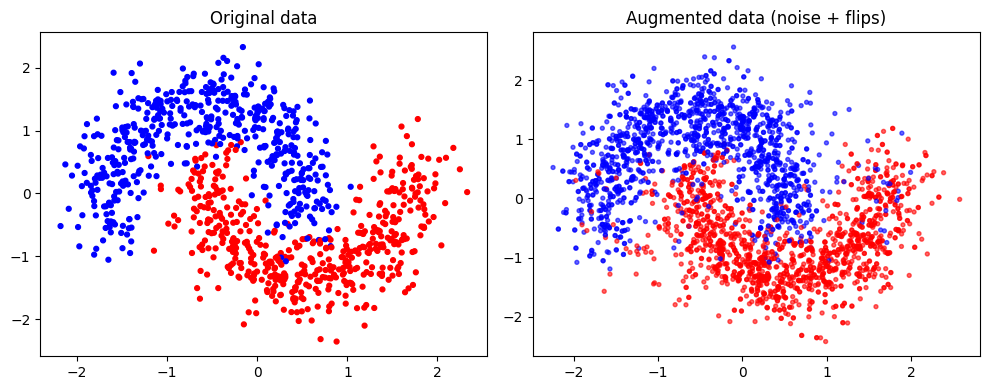

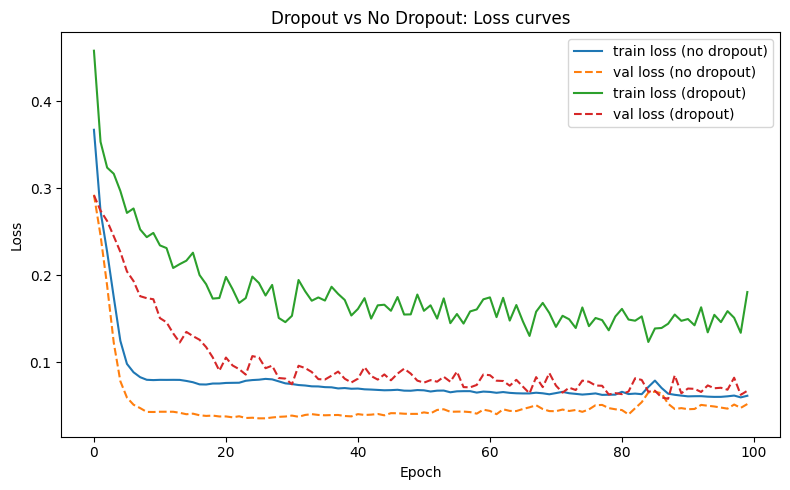

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers, losses, metrics, backend as K
import os
import random

# reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

def generate_data(n_samples=1000, noise=0.2):
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    return X.astype(np.float32), y.astype(np.int32)

def augment_data(X, y, noise_std=0.1, flip_prob=0.1):
    # Add Gaussian noise
    X_noise = X + np.random.normal(scale=noise_std, size=X.shape)
    y_noise = y.copy()
    # Random horizontal flips for some points (flip x coordinate)
    X_flip = X.copy()
    mask = (np.random.rand(len(X)) < flip_prob)
    X_flip[mask,0] = -X_flip[mask,0]
    # Combine: original + noise + flips (no label changes)
    X_aug = np.vstack([X, X_noise, X_flip])
    y_aug = np.concatenate([y, y_noise, y])
    return X_aug, y_aug

def plot_original_vs_aug(X, y, X_aug, y_aug, fname='augmentation.png'):
    fig, axes = plt.subplots(1,2, figsize=(10,4))
    axes[0].scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=12)
    axes[0].set_title('Original data')
    axes[1].scatter(X_aug[:,0], X_aug[:,1], c=y_aug, cmap='bwr', s=8, alpha=0.6)
    axes[1].set_title('Augmented data (noise + flips)')
    plt.tight_layout()
    plt.savefig(fname)
    print(f"Saved augmentation plot to {fname}")

def build_mlp(input_dim, hidden_units=(32,16), dropout_rate=0.0, use_batchnorm=False, l2=0.0):
    reg = regularizers.l2(l2) if l2>0 else None
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for idx, units in enumerate(hidden_units):
        model.add(layers.Dense(units, activation=None, kernel_regularizer=reg))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        if dropout_rate>0:
            model.add(layers.Dropout(dropout_rate))
    # output
    model.add(layers.Dense(1, activation='sigmoid', kernel_regularizer=reg))
    model.compile(optimizer=optimizers.Adam(learning_rate=0.01),
                  loss=losses.BinaryCrossentropy(),
                  metrics=[metrics.BinaryAccuracy()])
    return model

def train_and_history(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=32, verbose=0):
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=epochs, batch_size=batch_size, verbose=verbose)
    return hist

def evaluate_epochs_to_accuracy(model_builder_fn, X_train, y_train, threshold=0.90, max_epochs=200):
    """
    Train and return epochs needed to reach threshold training accuracy.
    If not reached, returns None and prints final acc.
    """
    model = model_builder_fn()
    for epoch in range(1, max_epochs+1):
        hist = model.fit(X_train, y_train, epochs=1, batch_size=32, verbose=0)
        acc = hist.history['binary_accuracy'][-1]
        if acc >= threshold:
            return epoch, model
    # not reached
    final_acc = float(model.evaluate(X_train, y_train, verbose=0)[1])
    return None, model

def compute_weight_norms(model):
    """
    Compute the L2 norm of only the kernel weights (exclude biases and BN params).
    """
    total_norm = 0.0
    for layer in model.layers:
        if hasattr(layer, "kernel"):  # Dense/Conv layers have kernels
            w = layer.kernel.numpy()
            total_norm += np.sum(np.square(w))
    return np.sqrt(total_norm)


# --------------------------
# MAIN: run requested experiments
# --------------------------
if __name__ == '__main__':
    # Generate data
    X, y = generate_data(n_samples=1000, noise=0.2)
    # scale data
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)

    # Augmentation
    X_aug, y_aug = augment_data(Xs, y, noise_std=0.15, flip_prob=0.12)
    plot_original_vs_aug(Xs, y, X_aug, y_aug, fname='augmentation_plot.png')

    # create train/val split for experiments
    X_train, X_val, y_train, y_val = train_test_split(Xs, y, test_size=0.2, random_state=seed)

    # Dropout experiment (two models: with and without dropout)
    model_no_dropout = build_mlp(input_dim=2, hidden_units=(32,16), dropout_rate=0.0, use_batchnorm=False, l2=0.0)
    model_dropout = build_mlp(input_dim=2, hidden_units=(32,16), dropout_rate=0.5, use_batchnorm=False, l2=0.0)

    epochs = 100
    hist_no = train_and_history(model_no_dropout, X_train, y_train, X_val, y_val, epochs=epochs, verbose=0)
    hist_do = train_and_history(model_dropout, X_train, y_train, X_val, y_val, epochs=epochs, verbose=0)

    # Plot training & validation loss curves
    plt.figure(figsize=(8,5))
    plt.plot(hist_no.history['loss'], label='train loss (no dropout)')
    plt.plot(hist_no.history['val_loss'], label='val loss (no dropout)', linestyle='--')
    plt.plot(hist_do.history['loss'], label='train loss (dropout)')
    plt.plot(hist_do.history['val_loss'], label='val loss (dropout)', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Dropout vs No Dropout: Loss curves')
    plt.tight_layout()
    plt.savefig('dropout_loss_curves.png')
    print("Saved dropout loss curves to dropout_loss_curves.png")

    # Batch Normalization experiment
    mb_no_bn = lambda: build_mlp(input_dim=2, hidden_units=(32,16), dropout_rate=0.0, use_batchnorm=False, l2=0.0)
    mb_with_bn = lambda: build_mlp(input_dim=2, hidden_units=(32,16), dropout_rate=0.0, use_batchnorm=True, l2=0.0)

    # Find epochs to reach 90% training accuracy (or report not reached)
    epochs_needed_no_bn, model_no_bn_trained = evaluate_epochs_to_accuracy(mb_no_bn, X_train, y_train, threshold=0.90, max_epochs=200)
    epochs_needed_with_bn, model_with_bn_trained = evaluate_epochs_to_accuracy(mb_with_bn, X_train, y_train, threshold=0.90, max_epochs=200)

    print("BatchNorm experiment: epochs to reach 90% train accuracy:")
    print(" - Without BN:", epochs_needed_no_bn)
    print(" - With BN:", epochs_needed_with_bn)

    # Hyperparameter tuning with 5-fold CV
    archs = {
        'arch_16_8': (16,8),
        'arch_32_16': (32,16),
        'arch_64_32': (64,32)
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    results = {}
    X_full = Xs
    y_full = y

    for name, hidden in archs.items():
        val_accs = []
        fold = 0
        for train_index, val_index in kf.split(X_full):
            fold += 1
            Xt, Xv = X_full[train_index], X_full[val_index]
            yt, yv = y_full[train_index], y_full[val_index]
            model = build_mlp(input_dim=2, hidden_units=hidden, dropout_rate=0.0, use_batchnorm=False, l2=0.0)
            model.fit(Xt, yt, epochs=80, batch_size=32, verbose=0)
            loss, acc = model.evaluate(Xv, yv, verbose=0)
            val_accs.append(acc)
        mean_acc = float(np.mean(val_accs))
        results[name] = mean_acc
        print(f"{name}: fold accuracies = {np.round(val_accs,4)}, mean = {mean_acc:.4f}")

    best_arch = max(results, key=results.get)
    print("Best architecture (5-fold mean val accuracy):", best_arch, "with mean acc =", results[best_arch])

    # Regularization (L2) experiment
    # Train two models on same training/val split: no L2 vs L2
    model_no_l2 = build_mlp(input_dim=2, hidden_units=(64,32), dropout_rate=0.0, use_batchnorm=False, l2=0.0)
    model_l2 = build_mlp(input_dim=2, hidden_units=(64,32), dropout_rate=0.0, use_batchnorm=False, l2=1e-3)

    hist_nl2 = train_and_history(model_no_l2, X_train, y_train, X_val, y_val, epochs=120, verbose=0)
    hist_l2 = train_and_history(model_l2, X_train, y_train, X_val, y_val, epochs=120, verbose=0)

    # Print final losses and average weight norm
    final_train_loss_no = hist_nl2.history['loss'][-1]
    final_val_loss_no = hist_nl2.history['val_loss'][-1]
    norm_no = compute_weight_norms(model_no_l2)

    final_train_loss_l2 = hist_l2.history['loss'][-1]
    final_val_loss_l2 = hist_l2.history['val_loss'][-1]
    norm_l2 = compute_weight_norms(model_l2)

    print("\nRegularization experiment results:")
    print(f"No L2     - train loss: {final_train_loss_no:.4f}, val loss: {final_val_loss_no:.4f}, weight-norm: {norm_no:.4f}")
    print(f"With L2(1e-3) - train loss: {final_train_loss_l2:.4f}, val loss: {final_val_loss_l2:.4f}, weight-norm: {norm_l2:.4f}")

